<a href="https://colab.research.google.com/github/demkin84-cyber/Cpp.mode1/blob/main/Object_yolov5_identifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/ultralytics/yolov5.git
%cd yolov5
!pip install -r requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 18406, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 18406 (delta 51), reused 31 (delta 23), pack-reused 18323 (from 3)
Receiving objects: 100% (18406/18406), 17.52 MiB | 16.86 MiB/s, done.
Resolving deltas: 100% (12500/12500), done.
/content/yolov5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 15.5 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [2]:
import torchvision
torchvision.datasets.VOCDetection(
    root='/content/VOC',
    year='2012',
    image_set='train',
    download=True
)

100%|██████████| 2.00G/2.00G [01:52<00:00, 17.8MB/s]


Dataset VOCDetection
    Number of datapoints: 5717
    Root location: /content/VOC

In [3]:
!find /content/VOC -type d | head -20

/content/VOC
/content/VOC/VOCdevkit
/content/VOC/VOCdevkit/VOC2012
/content/VOC/VOCdevkit/VOC2012/JPEGImages
/content/VOC/VOCdevkit/VOC2012/Annotations
/content/VOC/VOCdevkit/VOC2012/SegmentationClass
/content/VOC/VOCdevkit/VOC2012/ImageSets
/content/VOC/VOCdevkit/VOC2012/ImageSets/Layout
/content/VOC/VOCdevkit/VOC2012/ImageSets/Segmentation
/content/VOC/VOCdevkit/VOC2012/ImageSets/Action
/content/VOC/VOCdevkit/VOC2012/ImageSets/Main
/content/VOC/VOCdevkit/VOC2012/SegmentationObject


In [5]:
import xml.etree.ElementTree as ET
import os
import shutil

CLASSES = ['aeroplane','bicycle','bird','boat','bottle','bus','car',
           'cat','chair','cow','diningtable','dog','horse','motorbike',
           'person','pottedplant','sheep','sofa','train','tvmonitor']

def convert(size, box):
    dw, dh = 1./size[0], 1./size[1]
    x = (box[0] + box[1])/2.0
    y = (box[2] + box[3])/2.0
    w = box[1] - box[0]
    h = box[3] - box[2]
    return x*dw, y*dh, w*dw, h*dh

os.makedirs("/content/yolov5/yolov5/VOC_yolo/images/train", exist_ok=True)
os.makedirs("/content/yolov5/yolov5/VOC_yolo/labels/train", exist_ok=True)

ann_path = "/content/VOC/VOCdevkit/VOC2012/Annotations/"
img_path = "/content/VOC/VOCdevkit/VOC2012/JPEGImages/"

for xml_file in os.listdir(ann_path):
    tree = ET.parse(ann_path + xml_file)
    root = tree.getroot()
    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)

    label_file = open("/content/yolov5/yolov5/VOC_yolo/labels/train/" + xml_file.replace(".xml", ".txt"), "w")
    for obj in root.iter("object"):
        cls = obj.find("name").text
        if cls not in CLASSES:
            continue
        cls_id = CLASSES.index(cls)
        bb = obj.find("bndbox")
        b = (float(bb.find("xmin").text), float(bb.find("xmax").text),
             float(bb.find("ymin").text), float(bb.find("ymax").text))
        bb = convert((w, h), b)
        label_file.write(str(cls_id) + " " + " ".join([str(a) for a in bb]) + "\n")
    label_file.close()

    shutil.copy(img_path + xml_file.replace(".xml", ".jpg"),
                "/content/yolov5/yolov5/VOC_yolo/images/train/")

print("Done! Files converted:", len(os.listdir("/content/yolov5/yolov5/VOC_yolo/images/train")))

Done! Files converted: 17125


In [7]:
with open('VOC.yaml', 'w') as f:
    f.write("""train: /content/yolov5/yolov5/VOC_yolo/images/train
val: /content/yolov5/yolov5/VOC_yolo/images/train

nc: 20
names: ['aeroplane','bicycle','bird','boat','bottle','bus','car',
        'cat','chair','cow','diningtable','dog','horse','motorbike',
        'person','pottedplant','sheep','sofa','train','tvmonitor']
""")

In [8]:
!python train.py --img 640 --batch 16 --epochs 3 --data VOC.yaml --weights yolov5s.pt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=VOC.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=3, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data

In [10]:
!python detect.py --weights runs/train/exp/weights/best.pt --img 640 --source /content/yolov5/yolov5/VOC_yolo/images/train

Streaming output truncated to the last 5000 lines.
image 12128/17125 /content/yolov5/yolov5/VOC_yolo/images/train/2011_001592.jpg: 480x640 1 boat, 6.1ms
image 12129/17125 /content/yolov5/yolov5/VOC_yolo/images/train/2011_001594.jpg: 448x640 1 bicycle, 1 person, 6.4ms
image 12130/17125 /content/yolov5/yolov5/VOC_yolo/images/train/2011_001596.jpg: 480x640 4 cars, 6.2ms
image 12131/17125 /content/yolov5/yolov5/VOC_yolo/images/train/2011_001597.jpg: 640x448 1 cat, 6.5ms
image 12132/17125 /content/yolov5/yolov5/VOC_yolo/images/train/2011_001599.jpg: 480x640 1 person, 5.9ms
image 12133/17125 /content/yolov5/yolov5/VOC_yolo/images/train/2011_001600.jpg: 480x640 3 chairs, 5.9ms
image 12134/17125 /content/yolov5/yolov5/VOC_yolo/images/train/2011_001601.jpg: 480x640 1 cat, 8.6ms
image 12135/17125 /content/yolov5/yolov5/VOC_yolo/images/train/2011_001602.jpg: 480x640 1 person, 1 train, 6.3ms
image 12136/17125 /content/yolov5/yolov5/VOC_yolo/images/train/2011_001605.jpg: 448x640 1 motorbike, 2 pers

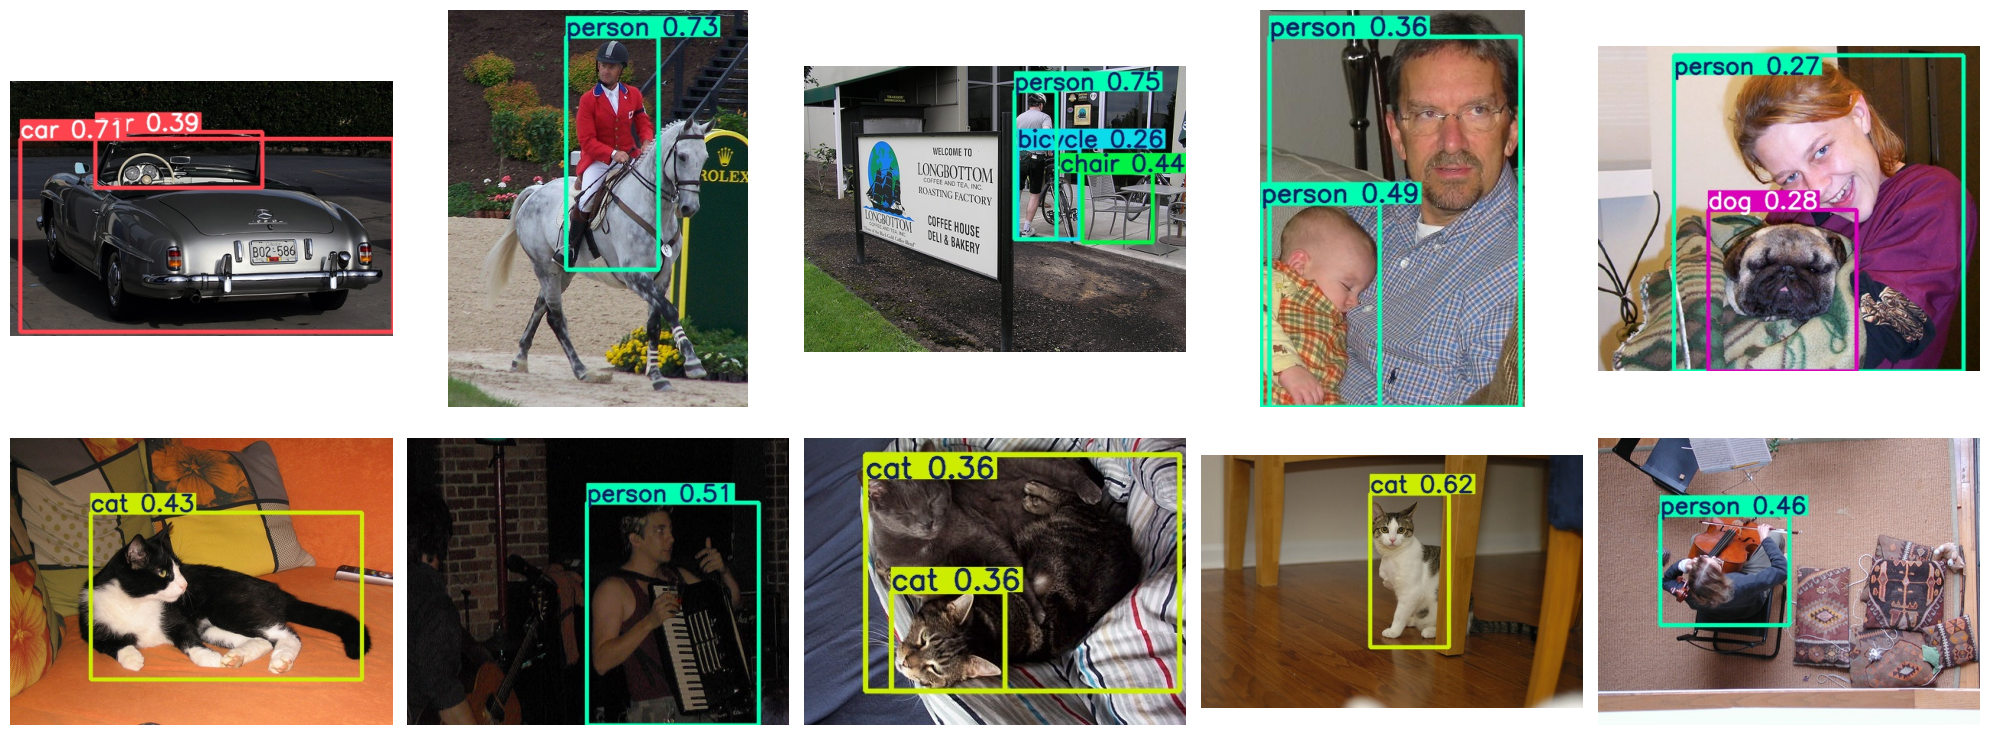

In [11]:
import glob
import matplotlib.pyplot as plt
from PIL import Image

results = glob.glob('runs/detect/exp/*.jpg')[:10]
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, path in enumerate(results):
    axes[i].imshow(Image.open(path))
    axes[i].axis('off')

plt.tight_layout()
plt.show()